In [1]:
!uv run try.py

Converted /home/nikhil/jukedrummer/data/audio/target/za_59_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/za_59_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/jy_64_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/jy_64_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/107_segment_3.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/107_segment_3.wav
Converted /home/nikhil/jukedrummer/data/audio/target/za_97_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/za_97_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/jy_16_segment_5.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/jy_16_segment_5.wav
Converted /home/nikhil/jukedrummer/data/audio/target/zz_41_segment_2.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/zz_41_segment_2.wav
Converted /home/nikhil/jukedrummer/data/audio/target/zz_47_segment_2.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/zz_47_segment_2.wav
Con

In [8]:
import os
from pydub import AudioSegment

def mp3_to_wav_dir(input_dir, output_dir=None):
    if output_dir is None:
        output_dir = input_dir

    os.makedirs(output_dir, exist_ok=True)

    for fname in os.listdir(input_dir):
        fpath = os.path.join(input_dir, fname)

        if not os.path.isfile(fpath):
            continue

        lower = fname.lower()

        if lower.endswith(".mp3") or lower.endswith(".mp3.wav"):
            # remove both ".wav" and ".mp3" if present
            base = fname
            if base.lower().endswith(".wav"):
                base = base.rsplit(".", 1)[0]
            if base.lower().endswith(".mp3"):
                base = base.rsplit(".", 1)[0]

            out_path = os.path.join(output_dir, f"{base}.wav")

            try:
                audio = AudioSegment.from_file(fpath, format="mp3")
                audio.export(out_path, format="wav")
                print(f"Converted: {fname} -> {out_path}")
            except Exception as e:
                print(f"Failed to convert {fname}: {e}")

        elif lower.endswith(".wav"):
            print(f"Skipping existing wav: {fname}")


# Example usage:
mp3_to_wav_dir("/home/nikhil/jukedrummer/30s_audio", "/home/nikhil/jukedrummer/30s_audio_wav")


Converted: 156_segment_1_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/156_segment_1_01.wav
Converted: jy_50_segment_4_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/jy_50_segment_4_01.wav
Converted: jy_60_segment_2_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/jy_60_segment_2_01.wav
Converted: 161_segment_6_02.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/161_segment_6_02.wav
Converted: jy_35_segment_4_02.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/jy_35_segment_4_02.wav
Converted: 144_segment_2_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/144_segment_2_01.wav
Converted: za_32_segment_1_02.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/za_32_segment_1_02.wav
Converted: 214_segment_2_02.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/214_segment_2_02.wav
Converted: 102_segment_2_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/102_segment_2_01.wav
Converted: zz_30_segment_5_01.mp3 -> /home/nikhil/jukedrummer/30s_audio_wav/zz_30_segment_5_01.wav
Converted: jy_48_segment_3_02.

In [4]:
!rm -r /home/nikhil/jukedrummer/30s_audio_wav/*

In [1]:
import os
import subprocess
import shutil

# Paths
# input_directory = '/home/nikhil/jukedrummer/pansori_data'
input_directory = '/home/nikhil/jukedrummer/30s_audio_wav'

output_base_dir = '/home/nikhil/jukedrummer/30s_audio_separated'
# output_base_dir = '/home/nikhil/jukedrummer/demucs_output'

demucs_model = 'htdemucs'

vocals_directory = os.path.join(output_base_dir, 'vocals')
drums_directory = os.path.join(output_base_dir, 'drums')
os.makedirs(vocals_directory, exist_ok=True)
os.makedirs(drums_directory, exist_ok=True)

# List of supported audio formats
audio_files = [f for f in os.listdir(input_directory) if f.lower().endswith('.wav')]

for filename in audio_files:
    input_path = os.path.join(input_directory, filename)
    print(f"Processing: {filename}")

    # Run Demucs CLI
    try:
        subprocess.run(
            ['demucs', '--model', demucs_model, input_path],
            check=True
        )
    except subprocess.CalledProcessError as e:
        print(f"Error processing {filename}: {e}")
        continue

    # Locate Demucs output
    base_name = os.path.splitext(filename)[0]
    separated_path = os.path.join('separated', demucs_model, base_name)

    # Move vocals and drums
    vocals_file = os.path.join(separated_path, 'vocals.wav')
    drums_file = os.path.join(separated_path, 'drums.wav')

    if os.path.exists(vocals_file):
        shutil.move(vocals_file, os.path.join(vocals_directory, f"{base_name}_vocals.wav"))
    if os.path.exists(drums_file):
        shutil.move(drums_file, os.path.join(drums_directory, f"{base_name}_drums.wav"))

    # Clean up the temporary separated folder
    shutil.rmtree(separated_path)

print("Demucs separation complete. Vocals and drums saved.")


Processing: 95_segment_2_01.wav
Error processing 95_segment_2_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/95_segment_2_01.wav']' returned non-zero exit status 1.
Processing: zz_83_segment_1_01.wav
Error processing zz_83_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/zz_83_segment_1_01.wav']' returned non-zero exit status 1.
Processing: zz_125_segment_5_01.wav


Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in distribution(dist_name).entry_points
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 542, in distribution
    return Distribution.from_name(distribution_name)
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 196, in from_name
    raise PackageNotFoundError(name)
importlib.metadata.PackageNotFoundError: demucs
Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in dist

Error processing zz_125_segment_5_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/zz_125_segment_5_01.wav']' returned non-zero exit status 1.
Processing: jy_51_segment_2_02.wav
Error processing jy_51_segment_2_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/jy_51_segment_2_02.wav']' returned non-zero exit status 1.
Processing: 204_segment_1_01.wav
Error processing 204_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/204_segment_1_01.wav']' returned non-zero exit status 1.
Processing: 147_segment_1_01.wav
Error processing 147_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/147_segment_1_01.wav']' returned non-zero exit status 1.
Processing: 125_segment_1_02.wav


Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in distribution(dist_name).entry_points
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 542, in distribution
    return Distribution.from_name(distribution_name)
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 196, in from_name
    raise PackageNotFoundError(name)
importlib.metadata.PackageNotFoundError: demucs
Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in dist

Error processing 125_segment_1_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/125_segment_1_02.wav']' returned non-zero exit status 1.
Processing: za_54_segment_2_02.wav
Error processing za_54_segment_2_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/za_54_segment_2_02.wav']' returned non-zero exit status 1.
Processing: 170_segment_1_02.wav
Error processing 170_segment_1_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/170_segment_1_02.wav']' returned non-zero exit status 1.
Processing: zz_126_segment_1_01.wav
Error processing zz_126_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/zz_126_segment_1_01.wav']' returned non-zero exit status 1.
Processing: 137_segment_3_01.wav


...

Error processing 228_segment_4_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/228_segment_4_02.wav']' returned non-zero exit status 1.
Processing: 131_segment_2_01.wav
Error processing 131_segment_2_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/131_segment_2_01.wav']' returned non-zero exit status 1.
Processing: jy_59_segment_1_02.wav
Error processing jy_59_segment_1_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/jy_59_segment_1_02.wav']' returned non-zero exit status 1.
Processing: zz_62_segment_1_01.wav
Error processing zz_62_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/zz_62_segment_1_01.wav']' returned non-zero exit status 1.
Processing: zz_37_segment_1_01.wav
Error processing zz_37_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/zz_37_segment_

Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in distribution(dist_name).entry_points
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 542, in distribution
    return Distribution.from_name(distribution_name)
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 196, in from_name
    raise PackageNotFoundError(name)
importlib.metadata.PackageNotFoundError: demucs
Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in dist

Error processing 135_segment_2_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/135_segment_2_01.wav']' returned non-zero exit status 1.
Processing: 210_segment_1_02.wav
Error processing 210_segment_1_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/210_segment_1_02.wav']' returned non-zero exit status 1.
Processing: za_95_segment_1_01.wav
Error processing za_95_segment_1_01.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/za_95_segment_1_01.wav']' returned non-zero exit status 1.
Processing: 124_segment_2_02.wav
Error processing 124_segment_2_02.wav: Command '['demucs', '--model', 'htdemucs', '/home/nikhil/jukedrummer/30s_audio_wav/124_segment_2_02.wav']' returned non-zero exit status 1.
Processing: 93_segment_5_02.wav


Traceback (most recent call last):
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 33, in <module>
    sys.exit(load_entry_point('demucs', 'console_scripts', 'demucs')())
  File "/home/nikhil/miniconda3/envs/demucs/bin/demucs", line 22, in importlib_load_entry_point
    for entry_point in distribution(dist_name).entry_points
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 542, in distribution
    return Distribution.from_name(distribution_name)
  File "/home/nikhil/miniconda3/envs/demucs/lib/python3.9/importlib/metadata.py", line 196, in from_name
    raise PackageNotFoundError(name)
importlib.metadata.PackageNotFoundError: demucs


KeyboardInterrupt: 

In [4]:
# run with no hup
!bash script/preprocessing.sh --no-hup

Step 3: divide into subsets
Comparing files in target and others... data/mel
segments_paths: data/mel/target
segments: ['za_35_segment_1.npy', 'za_27_segment_4.npy', '119_segment_2.npy', 'jy_63_segment_2.npy', 'zz_40_segment_5.npy', 'jy_64_segment_1.npy', 'zz_117_segment_4.npy', 'jy_56_segment_3.npy', '68_segment_1.npy', 'zz_27_segment_2.npy', 'jy_41_segment_2.npy', 'za_90_segment_2.npy', 'zz_52_segment_2.npy', 'jy_22_segment_3.npy', '76_segment_1.npy', 'zz_28_segment_2.npy', 'za_107_segment_1.npy', 'jy_61_segment_5.npy', '167_segment_3.npy', '204_segment_1.npy', '184_segment_3.npy', 'za_22_segment_4.npy', 'zz_131_segment_2.npy', 'zz_40_segment_4.npy', 'za_18_segment_2.npy', '178_segment_4.npy', '198_segment_1.npy', '209_segment_2.npy', 'za_93_segment_1.npy', 'zz_99_segment_5.npy', '177_segment_4.npy', '118_segment_3.npy', 'jy_41_segment_4.npy', 'jy_16_segment_1.npy', '196_segment_2.npy', 'zz_141_segment_5.npy', 'jy_51_segment_5.npy', 'zz_119_segment_2.npy', 'zz_38_segment_4.npy', 'jy_

In [2]:
!python3 train_vqvae.py --vq_idx 1 --data_type target --cuda 0

set up vq1 hparam
dataset[0] (train): ['198_segment_2.npy', '199_segment_1.npy', '199_segment_2.npy', '200_segment_1.npy', '200_segment_2.npy']
dataset[1] (valid): ['100_segment_1.npy', '100_segment_2.npy', '101_segment_1.npy', '101_segment_2.npy', '101_segment_3.npy']
Computing mean and std ...
Traceback (most recent call last):
  File "/home/nikhil/jukedrummer/train_vqvae.py", line 248, in <module>
    main()
  File "/home/nikhil/jukedrummer/train_vqvae.py", line 143, in main
    tr_loader, va_loader, mean, std = get_dataset(hps, args.data_type)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nikhil/jukedrummer/train_vqvae.py", line 55, in get_dataset
    mean, std, _ = compute_mean_std(os.path.join(hps['path'], 'mel', data_type), dataset)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nikhil/jukedrummer/dataset.py", line 53, in compute_mean_std
    raise ValueError("No valid data found to c

In [1]:
# run inference on an input dir get results from default files in output dirrectory
!python inference.py --exp_idx 1  --cuda 0 --input_dir /home/nikhil/jukedrummer/data_test/audio/others --output_dir /home/nikhil/jukedrummer/output --sample_iters 5 

setting up exp1 parameters
cuda: 0
bs  : 1
temp: 0.96
generate samples from /home/nikhil/jukedrummer/data_test/audio/others
save generated samples to /home/nikhil/jukedrummer/output
data/token/target/vq1
vq1_target.pkl
data/token/others/vq1
vq1_others.pkl
Traceback (most recent call last):
  File "/home/nikhil/jukedrummer/inference.py", line 82, in <module>
    lm.load_state_dict(lm_ckpt['model'])
  File "/home/nikhil/jukedrummer/jd1/lib/python3.12/site-packages/torch/nn/modules/module.py", line 2593, in load_state_dict
    raise RuntimeError(
RuntimeError: Error(s) in loading state_dict for JukeTransformer:
	size mismatch for prior.pos_emb.pos_emb: copying a param with shape torch.Size([1024, 512]) from checkpoint, the shape in current model is torch.Size([8192, 512]).
	size mismatch for prime_prior.pos_emb.pos_emb: copying a param with shape torch.Size([1024, 512]) from checkpoint, the shape in current model is torch.Size([8192, 512]).


Initializing Inference Process..
/home/nikhil/jukedrummer/jd1/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading '/home/nikhil/jukedrummer/hifi_gan/cp_hifigan_pansori/pansori_generator'
Complete.
Removing weight norm...
/home/nikhil/jukedrummer/output/43_segment_8_generated.wav


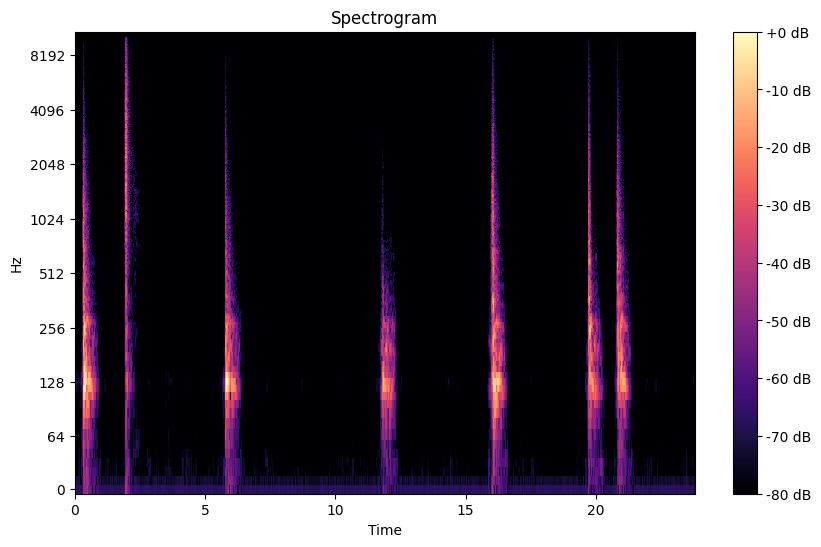

In [1]:
# visualise a spectrogram
audio = '/home/nikhil/jukedrummer/output/exp1/0_43_segment_8.wav'
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
y, sr = librosa.load(audio, sr=22050)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max
)
plt.figure(figsize=(10, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()

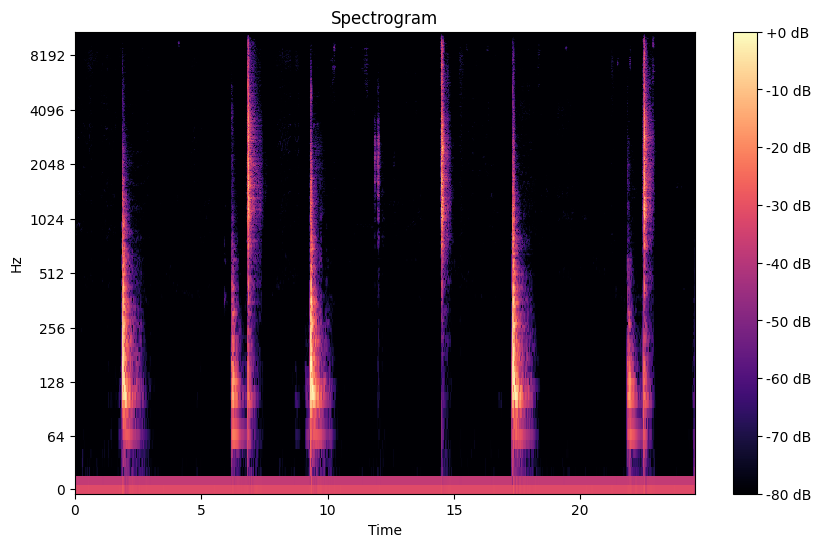

In [5]:
# visualise a spectrogram
audio = '/home/nikhil/jukedrummer/data_test/audio/target/43_segment_8.wav'
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
y, sr = librosa.load(audio, sr=22050)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max
)
plt.figure(figsize=(10, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()

Text(0.5, 1.0, 'Mel Spectrogram')

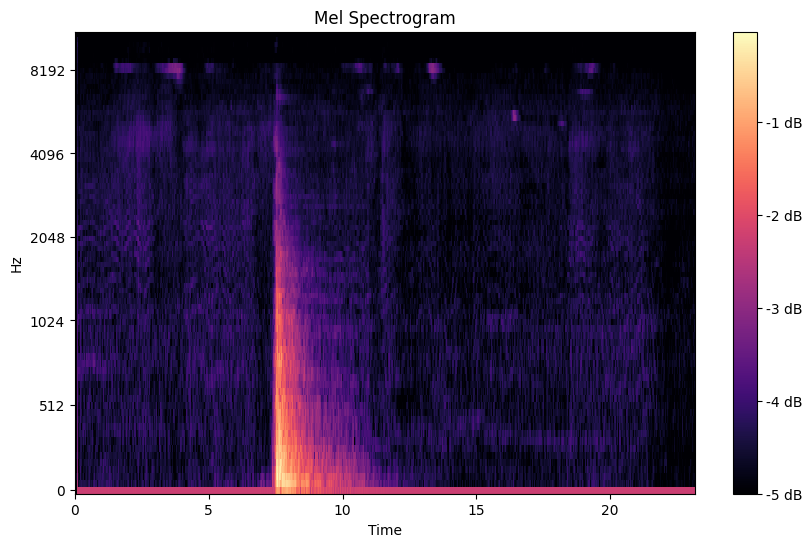

In [6]:
# visualise a spectrogram from numpy file
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
mel = np.load('/home/nikhil/jukedrummer/data/mel/target/43_segment_8.npy')
# clip to 23 seconds
if mel.shape[1] > 998:
    mel = mel[:, :998]
plt.figure(figsize=(10, 6))
librosa.display.specshow(mel, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')

In [18]:
import os
import torch
import numpy as np
import soundfile as sf
from tqdm import tqdm
from hparams import MEL
from utils.melspec import Audio2Mel
from utils.functions import get_vqvae

# -----------------------------
# Configuration
# -----------------------------
AUDIO_DIR = 'data/audio/target/'        # folder of wavs used for training
OUTPUT_DIR = './vqvae_mels'             # where reconstructed mels will be saved
VQ_IDX = 1                              # your retrained VQ-VAE index
CKPT_DIR = 'ckpt'                       # directory containing checkpoint
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Load HiFi-GAN mel extractor
# -----------------------------
hps = MEL
audiotomel = Audio2Mel(hps).to(DEVICE)
# ensure internal STFT window is on GPU
if hasattr(audiotomel, 'window'):
    audiotomel.window = audiotomel.window.to(DEVICE)

# -----------------------------
# Load VQ-VAE
# -----------------------------
vqvae, hps, mean, std = get_vqvae(
    vq_idx=VQ_IDX,
    data_type='target',
    ckpt_dir=CKPT_DIR,
    device=DEVICE
)
vqvae.eval()
vqvae = vqvae.to(DEVICE)

# move mean/std to device
mean = mean.to(DEVICE)
std = std.to(DEVICE)

# -----------------------------
# Processing loop
# -----------------------------
files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
for fname in tqdm(files, desc="Generating VQ-VAE mels"):
    path = os.path.join(AUDIO_DIR, fname)
    try:
        # 1. Load waveform
        wav, sr = sf.read(path)
        if sr != 44100:
            raise ValueError(f"Sample rate mismatch: expected 44100")

        # Convert stereo → mono if needed
        if wav.ndim > 1:
            wav = np.mean(wav, axis=1)

        # 2. Convert waveform → mel
        wav_t = torch.tensor(wav, dtype=torch.float32, device=DEVICE).unsqueeze(0)  # (1, N)
        mel = audiotomel(wav_t)                                                      # (1, n_mels, T)
        mel = mel.cpu().numpy()[0]                                                   # (n_mels, T)
        mel_t = torch.tensor(mel, dtype=torch.float32, device=DEVICE).unsqueeze(0)   # (1, n_mels, T)

        # normalize as in training
        mel_t = (mel_t - mean) / std

        # 3. Encode → quantize → decode
        with torch.no_grad():
            z = vqvae.encode(mel_t)
            mel_rec = vqvae.decode(z)    # reconstructed mel, shape (1, n_mels, T)

        mel_rec = mel_rec.squeeze(0).cpu().numpy()

        # 4. Save reconstructed mel
        out_path = os.path.join(OUTPUT_DIR, fname.replace('.wav', '.npy'))
        np.save(out_path, mel_rec)

    except Exception as e:
        print(f"[WARN] {fname}: {e}")


data/token/target/vq1
vq1_target.pkl


Generating VQ-VAE mels: 100%|██████████| 1579/1579 [03:42<00:00,  7.10it/s]
